# Hybrid BiLSTM–Transformer–CRF NER: Visualization Suite
CSCI-E-89B Final Project | Daniel R. Russell

<br>

This notebook assumes that:

- Gold annotations are span-based, with entities stored under `example["entities"]` as dictionaries with keys `{"type", "token_start", "token_end"}`.
- Tokens are fully aligned with these spans.
- Model predictions are stored in `pred_spans_all.pkl` as lists of `(label, start, end)` tuples in token index space.

Required artifacts in the working directory:

- `bio_examples.pkl`   (list of dev examples with keys `pmid`, `tokens`, `token_starts`, `token_ends`, `entities`)
- `pred_spans_all.pkl` (list of predicted spans for each dev example)
- `id2token.pkl`, `token2id.pkl` (optional; token index mappings)
- `transition_params.pkl` (optional; CRF transition matrix)
- `hybrid_ner_model_saved/` (optional; TensorFlow SavedModel for inspection)


## Generative AI Disclosure  

Portions of this notebook and accompanying documents were developed with reference to Generative AI tools (Copilot; ChatGPT, OpenAI, 2025 version), used in accordance with the course AI Technologies Policy including conceptual clarification, methodological guidance, validating code logic, identifying and resolving exceptions, and generating small code segments. All substantive decisions regarding problem formulation, dataset selection, model design, feasibility analysis, and implementation strategy are my own. All AI-generated code was independently reviewed, debugged, and validated for correctness before inclusion. 

## Imports and Configuration

In [1]:
import os
import pickle
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import tensorflow as tf

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = True

2025-12-12 21:52:43.429422: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-12 21:52:43.429494: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-12 21:52:43.431146: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-12 21:52:43.440832: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-12 21:52:44.707407: W tensorflow/compiler/tf2

## 1. Load saved artifacts

In [2]:
ARTIFACT_DIR = "."  # adjust if artifacts live in a subdirectory

def load_pickle(name):
    path = os.path.join(ARTIFACT_DIR, name)
    with open(path, "rb") as f:
        return pickle.load(f)

bio_examples = load_pickle("bio_examples.pkl")
pred_spans_all = load_pickle("pred_spans_all.pkl")

try:
    id2token = load_pickle("id2token.pkl")
    token2id = load_pickle("token2id.pkl")
    print("Loaded id2token and token2id.")
except FileNotFoundError:
    id2token = None
    token2id = None
    print("Token index mappings not found. Continuing without them.")

try:
    model = tf.keras.models.load_model(os.path.join(ARTIFACT_DIR, "hybrid_ner_model_saved"))
    print("Model loaded from hybrid_ner_model_saved/.")
except Exception as e:
    model = None
    print("Warning: could not load model. Most visualizations will still work.")
    print("Reason:", repr(e))

try:
    transition_params = load_pickle("transition_params.pkl")
    print("Loaded CRF transition_params of shape:", np.array(transition_params).shape)
except FileNotFoundError:
    transition_params = None
    print("transition_params.pkl not found. Skipping CRF-specific diagnostics.")

print(f"Number of dev examples in bio_examples: {len(bio_examples)}")
print(f"Number of prediction span lists in pred_spans_all: {len(pred_spans_all)}")

Loaded id2token and token2id.


2025-12-12 21:52:52.047528: W tensorflow/core/common_runtime/graph_constructor.cc:840] Node 'cond/while' has 14 outputs but the _output_shapes attribute specifies shapes for 44 outputs. Output shapes may be inaccurate.
2025-12-12 21:52:52.410267: W tensorflow/core/common_runtime/graph_constructor.cc:840] Node 'cond/while' has 14 outputs but the _output_shapes attribute specifies shapes for 44 outputs. Output shapes may be inaccurate.
2025-12-12 21:52:52.422489: W tensorflow/core/common_runtime/graph_constructor.cc:840] Node 'cond' has 5 outputs but the _output_shapes attribute specifies shapes for 44 outputs. Output shapes may be inaccurate.
2025-12-12 21:52:52.764652: W tensorflow/core/common_runtime/graph_constructor.cc:840] Node 'cond/while' has 14 outputs but the _output_shapes attribute specifies shapes for 44 outputs. Output shapes may be inaccurate.
2025-12-12 21:52:52.777777: W tensorflow/core/common_runtime/graph_constructor.cc:840] Node 'cond' has 5 outputs but the _output_sh

Model loaded from hybrid_ner_model_saved/.
Loaded CRF transition_params of shape: (5, 5)
Number of dev examples in bio_examples: 500
Number of prediction span lists in pred_spans_all: 500


## 2. Validate example structure

In [3]:
ex0 = bio_examples[0]
print("Keys in first example:", ex0.keys())
print("First example tokens:", ex0["tokens"][:25])
print("First example entities:", ex0["entities"][:10])

sp0 = pred_spans_all[0]
print("\nFirst predicted span list (first 10 spans):", sp0[:10])

Keys in first example: dict_keys(['pmid', 'tokens', 'token_starts', 'token_ends', 'entities'])
First example tokens: ['Tricuspid', 'valve', 'regurgitation', 'and', 'lithium', 'carbonate', 'toxicity', 'in', 'a', 'newborn', 'infant', '.', 'A', 'newborn', 'with', 'massive', 'tricuspid', 'regurgitation', ',', 'atrial', 'flutter', ',', 'congestive', 'heart', 'failure']
First example entities: [{'type': 'Disease', 'token_start': 0, 'token_end': 3}, {'type': 'Chemical', 'token_start': 4, 'token_end': 6}, {'type': 'Disease', 'token_start': 6, 'token_end': 7}, {'type': 'Disease', 'token_start': 16, 'token_end': 18}, {'type': 'Disease', 'token_start': 19, 'token_end': 21}, {'type': 'Disease', 'token_start': 22, 'token_end': 25}, {'type': 'Chemical', 'token_start': 30, 'token_end': 31}, {'type': 'Disease', 'token_start': 43, 'token_end': 45}, {'type': 'Disease', 'token_start': 46, 'token_end': 48}, {'type': 'Disease', 'token_start': 55, 'token_end': 57}]

First predicted span list (first 10 spans

## 3. Helper functions for span-based labels

In [ ]:
from collections import defaultdict

def gold_spans_from_example(ex):
    spans = []
    for ent in ex.get("entities", []):
        lab = ent["type"]
        s = int(ent["token_start"])
        e = int(ent["token_end"])
        spans.append((lab, s, e))
    return spans

# [Gen AI Log #1 / Initialization]
def flatten_token_labels_from_spans(examples, pred_spans_all):
    gold_labels = []
    pred_labels = []

    for ex, pred_spans in zip(examples, pred_spans_all):
        tokens = ex["tokens"]
        n = len(tokens)
        g = ["O"] * n
        p = ["O"] * n

        for lab, s, e in gold_spans_from_example(ex):
            for t in range(max(0, s), min(e, n)):
                g[t] = lab

        for lab, s, e in pred_spans:
            for t in range(max(0, s), min(e, n)):
                p[t] = lab

        gold_labels.extend(g)
        pred_labels.extend(p)

    return gold_labels, pred_labels

## 4. Compute flattened token-level labels

In [5]:
gold_labels, pred_labels = flatten_token_labels_from_spans(bio_examples, pred_spans_all)

print("Total tokens (after flattening):", len(gold_labels))
print("Unique gold labels:", sorted(set(gold_labels)))
print("Unique predicted labels:", sorted(set(pred_labels)))

Total tokens (after flattening): 112768
Unique gold labels: ['Chemical', 'Disease', 'O']
Unique predicted labels: ['Chemical', 'Disease', 'O']


## 5. Token-level confusion matrix

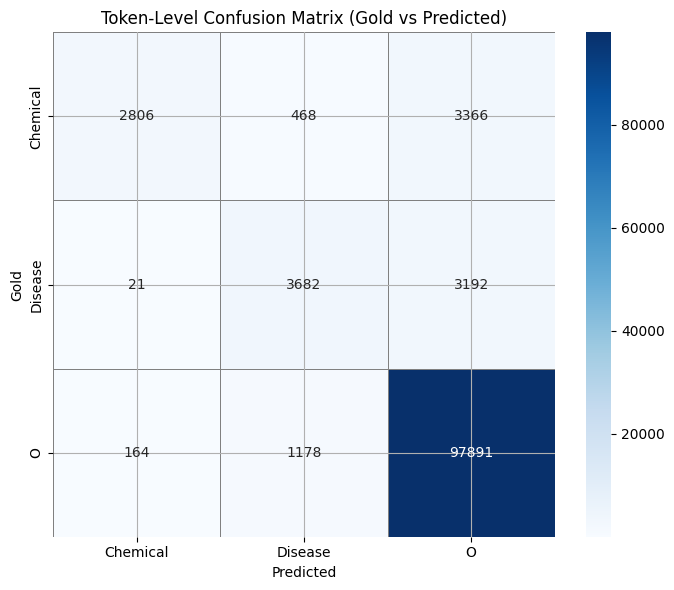

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute matrix
gold_lbls, pred_lbls = gold_labels, pred_labels
unique = sorted(set(gold_lbls) | set(pred_lbls))
cm = confusion_matrix(gold_lbls, pred_lbls, labels=unique)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=unique, yticklabels=unique,
            linewidths=0.5, linecolor="gray")

plt.title("Token-Level Confusion Matrix (Gold vs Predicted)")
plt.xlabel("Predicted")
plt.ylabel("Gold")
plt.tight_layout()
plt.show()


## 6. Token-level classification report

In [7]:
report = classification_report(gold_labels, pred_labels, labels=labels, zero_division=0)
print(report)

              precision    recall  f1-score   support

    Chemical       0.94      0.42      0.58      6640
     Disease       0.69      0.53      0.60      6895
           O       0.94      0.99      0.96     99233

    accuracy                           0.93    112768
   macro avg       0.86      0.65      0.72    112768
weighted avg       0.92      0.93      0.92    112768



## 7. Span-level evaluation

In [ ]:
def span_set_from_examples(examples, source="gold"):
    all_spans = set()
    for i, ex in enumerate(examples):
        n = len(ex["tokens"])
        if source == "gold":
            spans = gold_spans_from_example(ex)
        else:
            spans = pred_spans_all[i]
        for lab, s, e in spans:
            all_spans.add((i, lab, max(0, s), min(e, n)))
    return all_spans

# [Gen AI Log #2 / Aggregation]
gold_spans = span_set_from_examples(bio_examples, source="gold")
pred_spans = span_set_from_examples(bio_examples, source="pred")

tp = len(gold_spans & pred_spans)
fp = len(pred_spans - gold_spans)
fn = len(gold_spans - pred_spans)

precision = tp / (tp + fp) if tp + fp > 0 else 0.0
recall = tp / (tp + fn) if tp + fn > 0 else 0.0
f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0

print(f"Span-level counts: TP={tp}, FP={fp}, FN={fn}")
print(f"Span-level precision: {precision:.4f}")
print(f"Span-level recall:    {recall:.4f}")
print(f"Span-level F1:        {f1:.4f}")

Span-level counts: TP=4509, FP=2427, FN=5076
Span-level precision: 0.6501
Span-level recall:    0.4704
Span-level F1:        0.5459


## 8. Span length distribution (gold vs. predicted)

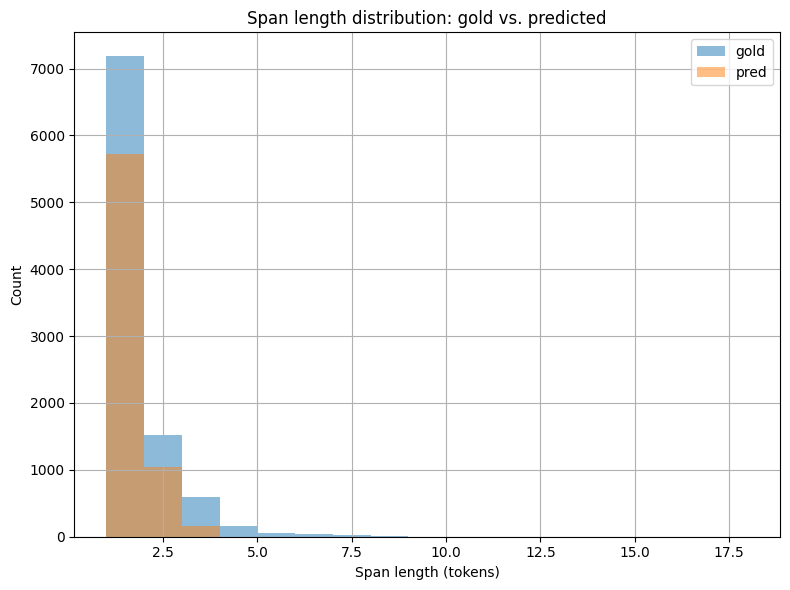

In [9]:
def span_lengths(spans):
    return [end - start for (_, _, start, end) in spans]

gold_lengths = span_lengths(gold_spans)
pred_lengths = span_lengths(pred_spans)

if gold_lengths or pred_lengths:
    bins = range(1, max(gold_lengths + pred_lengths + [1]) + 1)

    fig, ax = plt.subplots()
    ax.hist(gold_lengths, bins=bins, alpha=0.5, label="gold")
    ax.hist(pred_lengths, bins=bins, alpha=0.5, label="pred")
    ax.set_xlabel("Span length (tokens)")
    ax.set_ylabel("Count")
    ax.set_title("Span length distribution: gold vs. predicted")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No spans found to plot.")

## 9. Label-wise span precision and recall

In [10]:
def group_spans_by_label(spans):
    d = defaultdict(set)
    for (sent_id, lab, s, e) in spans:
        d[lab].add((sent_id, s, e))
    return d

gold_by_label = group_spans_by_label(gold_spans)
pred_by_label = group_spans_by_label(pred_spans)

labels_span = sorted(gold_by_label.keys() | pred_by_label.keys())
print("Label-wise span metrics:")
print("{:15s} {:>6s} {:>6s} {:>6s} {:>9s} {:>9s} {:>9s}".format(
    "Label", "TP", "FP", "FN", "Precision", "Recall", "F1"))

for lab in labels_span:
    g = gold_by_label.get(lab, set())
    p = pred_by_label.get(lab, set())
    tp_l = len(g & p)
    fp_l = len(p - g)
    fn_l = len(g - p)
    prec_l = tp_l / (tp_l + fp_l) if tp_l + fp_l > 0 else 0.0
    rec_l = tp_l / (tp_l + fn_l) if tp_l + fn_l > 0 else 0.0
    f1_l = 2 * prec_l * rec_l / (prec_l + rec_l) if prec_l + rec_l > 0 else 0.0
    print("{:15s} {:6d} {:6d} {:6d} {:9.4f} {:9.4f} {:9.4f}".format(
        lab, tp_l, fp_l, fn_l, prec_l, rec_l, f1_l))

Label-wise span metrics:
Label               TP     FP     FN Precision    Recall        F1
Chemical          2463    400   2878    0.8603    0.4611    0.6004
Disease           2046   2027   2198    0.5023    0.4821    0.4920


## 10. Qualitative error inspection

In [ ]:
def inspect_example(idx, max_tokens=120):
    ex = bio_examples[idx]
    tokens = ex["tokens"]
    spans_gold = gold_spans_from_example(ex)
    spans_pred = pred_spans_all[idx]

    print(f"Example {idx}")
    print("Tokens:")
    print(" ".join(tokens[:max_tokens]))
    print("\nGold spans:")
    for lab, s, e in spans_gold:
        print(f"  {lab:10s} [{s:3d}, {e:3d}):", " ".join(tokens[s:e]))
    print("\nPred spans:")
    for lab, s, e in spans_pred:
        print(f"  {lab:10s} [{s:3d}, {e:3d}):", " ".join(tokens[s:e]))

# [Gen AI Log #3 / Identification]
mismatched_indices = []
for i, ex in enumerate(bio_examples):
    g_spans = set(gold_spans_from_example(ex))
    p_spans = set(pred_spans_all[i])
    if g_spans != p_spans:
        mismatched_indices.append(i)

print(f"Found {len(mismatched_indices)} dev examples with span mismatches.")
if mismatched_indices:
    print("First 10 mismatched indices:", mismatched_indices[:10])

# Usage:
# inspect_example(mismatched_indices[0])

Found 495 dev examples with span mismatches.
First 10 mismatched indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


## Span-level error heatmap (per token position)

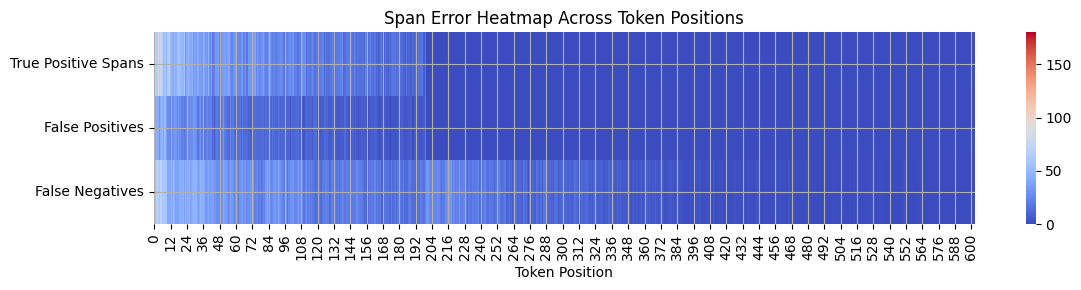

In [13]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

max_len = max(len(ex["tokens"]) for ex in bio_examples)
err_matrix = np.zeros((3, max_len))   # rows = [TP, FP, FN]

for i, ex in enumerate(bio_examples):
    n = len(ex["tokens"])
    gold = set((l, s, e) for l, s, e in gold_spans_from_example(ex))
    pred = set((l, s, e) for l, s, e in pred_spans_all[i])

    tp = gold & pred
    fp = pred - gold
    fn = gold - pred

    for (_, s, e) in tp:
        err_matrix[0, s:e] += 1
    for (_, s, e) in fp:
        err_matrix[1, s:e] += 1
    for (_, s, e) in fn:
        err_matrix[2, s:e] += 1

plt.figure(figsize=(12, 3))
sns.heatmap(err_matrix, cmap="coolwarm", cbar=True,
            yticklabels=["True Positive Spans", "False Positives", "False Negatives"])
plt.title("Span Error Heatmap Across Token Positions")
plt.xlabel("Token Position")
plt.tight_layout()
plt.show()


## Boundary confusion heatmap (start vs end errors)

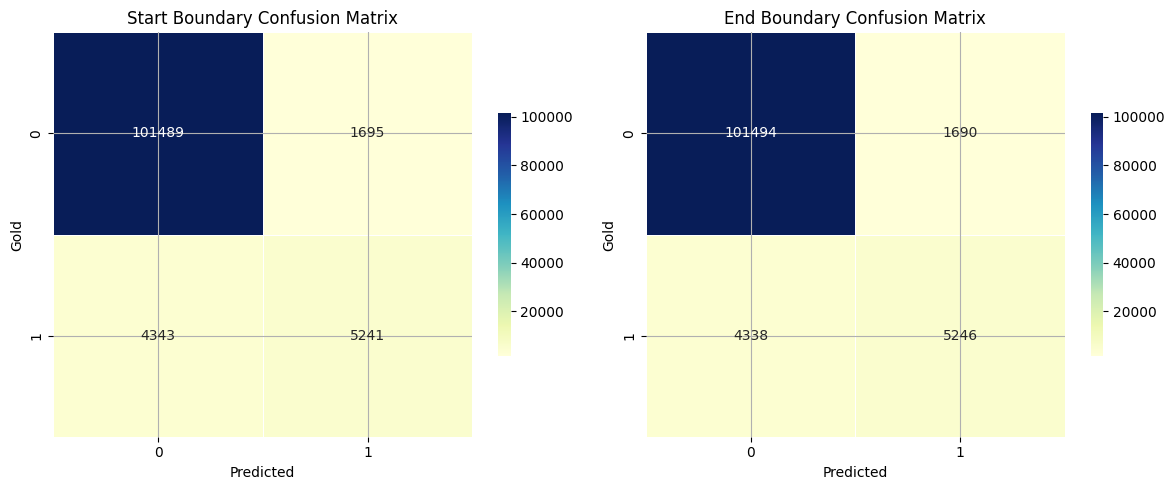

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

gold_start = []
pred_start = []
gold_end = []
pred_end = []

# iterate through dev examples
for ex, pred_spans in zip(bio_examples, pred_spans_all):
    gold_spans = gold_spans_from_example(ex)

    # determine maximum token index for this example
    n = len(ex["tokens"])

    g_s = [0]*n; g_e = [0]*n
    p_s = [0]*n; p_e = [0]*n

    for _, s, e in gold_spans:
        g_s[s] = 1
        g_e[e-1] = 1

    for _, s, e in pred_spans:
        p_s[s] = 1
        p_e[e-1] = 1

    gold_start.extend(g_s); pred_start.extend(p_s)
    gold_end.extend(g_e);   pred_end.extend(p_e)

# confusion matrices
cm_start = confusion_matrix(gold_start, pred_start)
cm_end   = confusion_matrix(gold_end, pred_end)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Start boundary matrix
sns.heatmap(
    cm_start,
    annot=True,
    fmt="d",
    cmap="YlGnBu",      
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.6},
    ax=axes[0]
)
axes[0].set_title("Start Boundary Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Gold")

# End boundary matrix
sns.heatmap(
    cm_end,
    annot=True,
    fmt="d",
    cmap="YlGnBu",      
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.6},
    ax=axes[1]
)
axes[1].set_title("End Boundary Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Gold")

plt.tight_layout()
plt.show()

## Entity co-occurrence heatmap (new, high-value addition)

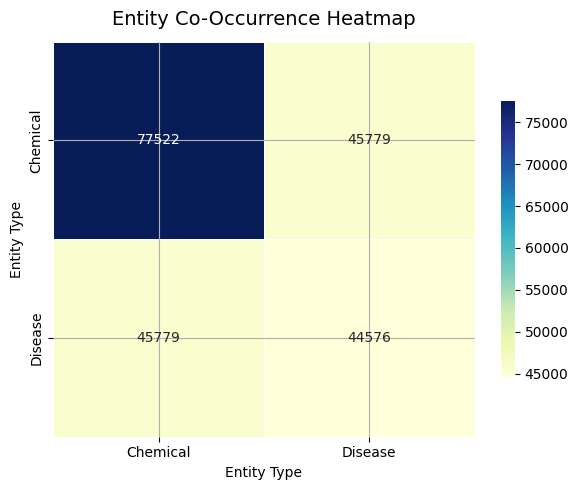

In [34]:
import itertools
import numpy as np
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt

pair_counts = Counter()

for ex in bio_examples:
    spans = gold_spans_from_example(ex)
    labels = [lab for (lab, _, _) in spans]
    for a, b in itertools.combinations(labels, 2):
        pair_counts[tuple(sorted((a, b)))] += 1

uniq_labels = sorted(set(labels for ex in bio_examples 
                         for (labels, _, _) in gold_spans_from_example(ex)))

label_index = {lab: i for i, lab in enumerate(uniq_labels)}
matrix = np.zeros((len(uniq_labels), len(uniq_labels)))

for (a, b), count in pair_counts.items():
    i, j = label_index[a], label_index[b]
    matrix[i, j] += count
    matrix[j, i] += count

plt.figure(figsize=(6, 5))

sns.heatmap(
    matrix,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",          
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.7},
    xticklabels=uniq_labels,
    yticklabels=uniq_labels,
)

plt.title("Entity Co-Occurrence Heatmap", fontsize=14, pad=12)
plt.xlabel("Entity Type")
plt.ylabel("Entity Type")
plt.tight_layout()
plt.show()



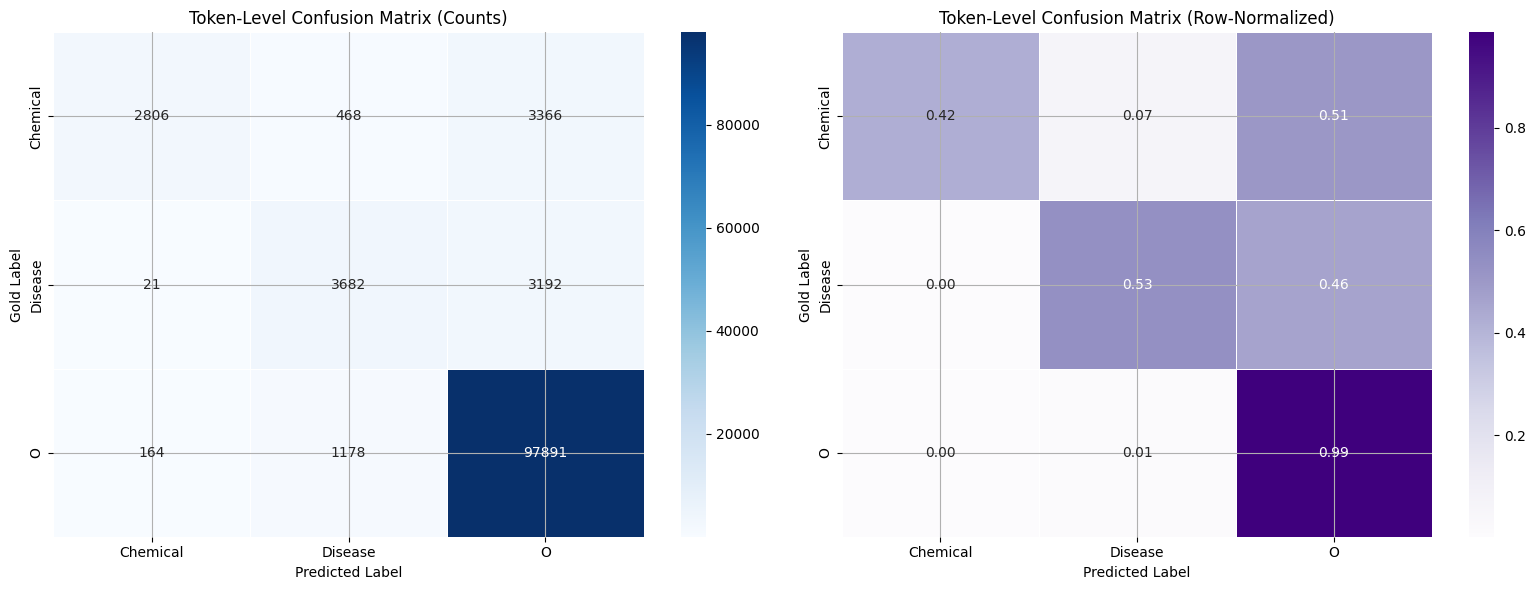

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Build confusion matrix
labels = sorted(set(gold_labels) | set(pred_labels))
cm = confusion_matrix(gold_labels, pred_labels, labels=labels)

# Optionally compute normalized matrix
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts heatmap 
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0]
)

axes[0].set_title("Token-Level Confusion Matrix (Counts)")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("Gold Label")

# Normalized heatmap 
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Purples",
    linewidths=0.5,
    linecolor="white",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[1]
)

axes[1].set_title("Token-Level Confusion Matrix (Row-Normalized)")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("Gold Label")

plt.tight_layout()
plt.show()


## Span Boundary Shift Histogram

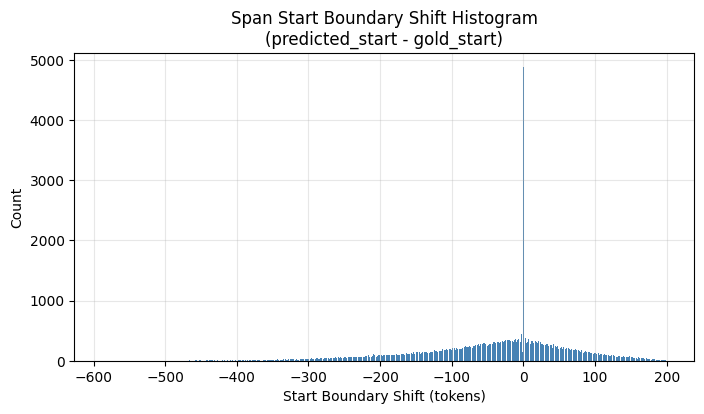

In [35]:
import matplotlib.pyplot as plt
from collections import Counter

shift_counts = Counter()

for ex, pred_spans in zip(bio_examples, pred_spans_all):
    gold_spans = gold_spans_from_example(ex)

    for g_lab, g_s, g_e in gold_spans:
        # match predicted spans with same label
        for p_lab, p_s, p_e in pred_spans:
            if g_lab == p_lab:
                shift = p_s - g_s
                shift_counts[shift] += 1

shifts = sorted(shift_counts.keys())
values = [shift_counts[s] for s in shifts]

plt.figure(figsize=(8, 4))
plt.bar(shifts, values, color="steelblue")
plt.title("Span Start Boundary Shift Histogram\n(predicted_start - gold_start)")
plt.xlabel("Start Boundary Shift (tokens)")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()


## 2. Span-Length Recall Curve

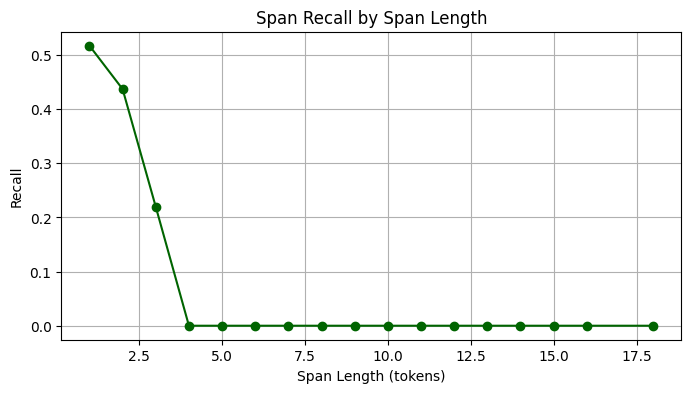

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

length_tp = defaultdict(int)
length_fn = defaultdict(int)

for ex, pred_spans in zip(bio_examples, pred_spans_all):
    gold_spans = gold_spans_from_example(ex)
    gold_set = set(gold_spans)
    pred_set = set(pred_spans)

    for lab, s, e in gold_spans:
        length = e - s
        if (lab, s, e) in pred_set:
            length_tp[length] += 1
        else:
            length_fn[length] += 1

lengths = sorted(set(length_tp.keys()) | set(length_fn.keys()))
recall_values = [
    length_tp[L] / (length_tp[L] + length_fn[L]) if (length_tp[L] + length_fn[L])>0 else 0
    for L in lengths
]

plt.figure(figsize=(8, 4))
plt.plot(lengths, recall_values, marker="o", color="darkgreen")
plt.title("Span Recall by Span Length")
plt.xlabel("Span Length (tokens)")
plt.ylabel("Recall")
plt.grid(True)
plt.show()

## FP Phrase Cloud (non-wordcloud version: top FP tokens)

In [37]:
from collections import Counter

fp_tokens = Counter()

for ex, pred_spans in zip(bio_examples, pred_spans_all):
    gold_spans = set(gold_spans_from_example(ex))
    pred_set = set(pred_spans_all[bio_examples.index(ex)])
    
    # false positives = predicted spans not in gold
    fp_spans = pred_set - gold_spans
    toks = ex["tokens"]

    for lab, s, e in fp_spans:
        for t in toks[s:e]:
            fp_tokens[t.lower()] += 1

# Print top 20 FP token types
print("Top 20 False-Positive Tokens:")
for tok, cnt in fp_tokens.most_common(20):
    print(f"{tok:20s} {cnt}")


Top 20 False-Positive Tokens:
d                    38
syndrome             36
l                    34
ventricular          25
cerebral             25
hepatitis            22
's                   20
bone                 19
malignant            19
sinus                18
sexual               18
myocardial           17
liver                16
pain                 16
marrow               15
ht                   15
visual               15
failure              14
optic                14
venous               13


## Span Overlap Visualization (Text-Based)

In [38]:
def visualize_span_overlap(idx):
    ex = bio_examples[idx]
    toks = ex["tokens"]
    gold = gold_spans_from_example(ex)
    pred = pred_spans_all[idx]

    print(f"\nExample {idx}")
    print("Text:")
    print(" ".join(toks))

    print("\nGold spans:")
    for lab, s, e in gold:
        print(f"{lab:10s} [{s:2d}:{e:2d}]  {' '.join(toks[s:e])}")

    print("\nPred spans:")
    for lab, s, e in pred:
        print(f"{lab:10s} [{s:2d}:{e:2d}]  {' '.join(toks[s:e])}")

# Usage:
visualize_span_overlap(0)



Example 0
Text:
Tricuspid valve regurgitation and lithium carbonate toxicity in a newborn infant . A newborn with massive tricuspid regurgitation , atrial flutter , congestive heart failure , and a high serum lithium level is described . This is the first patient to initially manifest tricuspid regurgitation and atrial flutter , and the 11th described patient with cardiac disease among infants exposed to lithium compounds in the first trimester of pregnancy . Sixty - three percent of these infants had tricuspid valve involvement . Lithium carbonate may be a factor in the increasing incidence of congenital heart disease when taken during early pregnancy . It also causes neurologic depression , cyanosis , and cardiac arrhythmia when consumed prior to delivery .

Gold spans:
Disease    [ 0: 3]  Tricuspid valve regurgitation
Chemical   [ 4: 6]  lithium carbonate
Disease    [ 6: 7]  toxicity
Disease    [16:18]  tricuspid regurgitation
Disease    [19:21]  atrial flutter
Disease    [22:25]  

## Entity Frequency vs F1 Scatter Plot

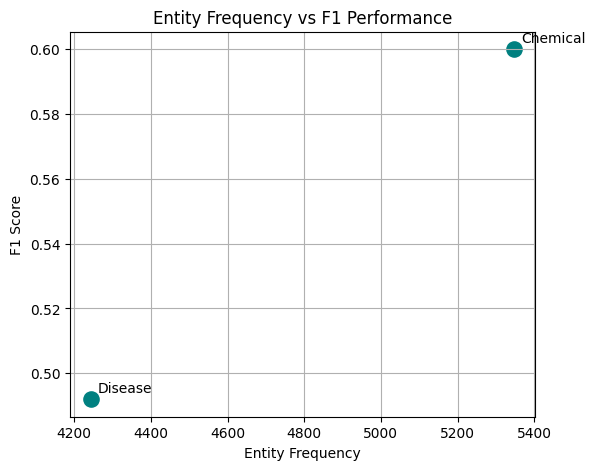

In [39]:
from collections import defaultdict
import matplotlib.pyplot as plt

tp = defaultdict(int)
fp = defaultdict(int)
fn = defaultdict(int)
freq = defaultdict(int)

for ex, pred_spans in zip(bio_examples, pred_spans_all):
    gold = gold_spans_from_example(ex)
    gold_set = set(gold)
    pred_set = set(pred_spans)

    for lab, s, e in gold:
        freq[lab] += 1
        if (lab, s, e) in pred_set:
            tp[lab] += 1
        else:
            fn[lab] += 1

    for lab, s, e in pred_set:
        if (lab, s, e) not in gold_set:
            fp[lab] += 1

labels = sorted(freq.keys())
f1 = [
    (2*tp[L]) / (2*tp[L] + fp[L] + fn[L]) if (2*tp[L] + fp[L] + fn[L])>0 else 0
    for L in labels
]

plt.figure(figsize=(6, 5))
plt.scatter([freq[L] for L in labels], f1, s=120, color="teal")
for L in labels:
    plt.annotate(L, (freq[L], f1[labels.index(L)]), textcoords="offset points", xytext=(5,5))

plt.xlabel("Entity Frequency")
plt.ylabel("F1 Score")
plt.title("Entity Frequency vs F1 Performance")
plt.grid(True)
plt.show()

## Entity Position Density Plots

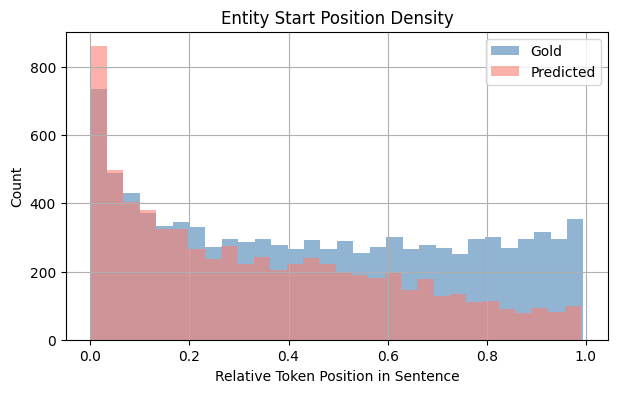

In [40]:
import numpy as np
import matplotlib.pyplot as plt

positions_gold = []
positions_pred = []

for ex, pred_spans in zip(bio_examples, pred_spans_all):
    gold = gold_spans_from_example(ex)
    n = len(ex["tokens"])
    
    positions_gold.extend([s / n for (_, s, _) in gold])
    positions_pred.extend([s / n for (_, s, _) in pred_spans])

plt.figure(figsize=(7, 4))
plt.hist(positions_gold, bins=30, alpha=0.6, label="Gold", color="steelblue")
plt.hist(positions_pred, bins=30, alpha=0.6, label="Predicted", color="salmon")
plt.title("Entity Start Position Density")
plt.xlabel("Relative Token Position in Sentence")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.show()


## CRF Transition Matrix Heatmap

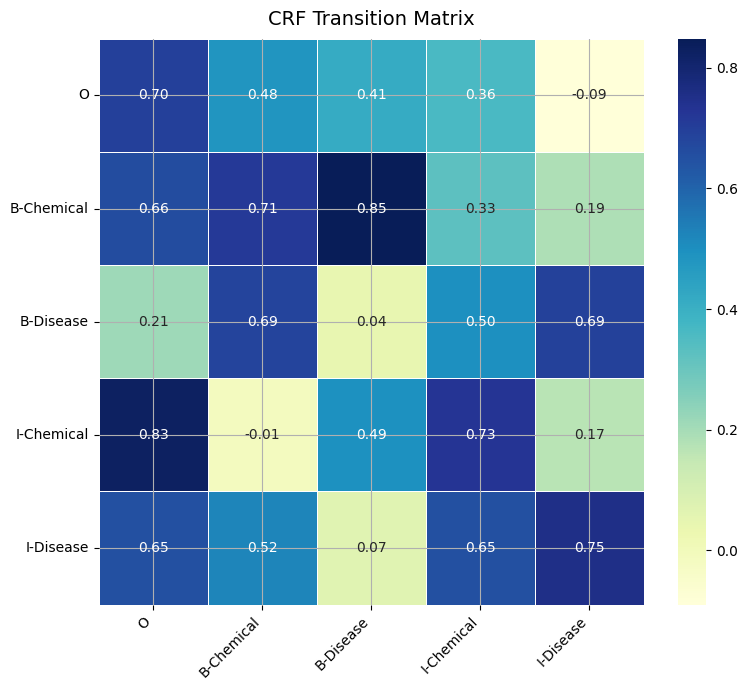

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

# Load transition parameters (matrix of shape [num_labels, num_labels])
with open("transition_params.pkl", "rb") as f:
    trans = pickle.load(f)

trans = np.array(trans)

# Manually define BIO label set since id2label.pkl is not present
labels = ["O", "B-Chemical", "B-Disease", "I-Chemical", "I-Disease"]

# Single final annotated heatmap 
plt.figure(figsize=(8, 7))
sns.heatmap(
    trans,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor="white"
)

plt.title("CRF Transition Matrix", fontsize=14, pad=10)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Span Error Galaxy Plot

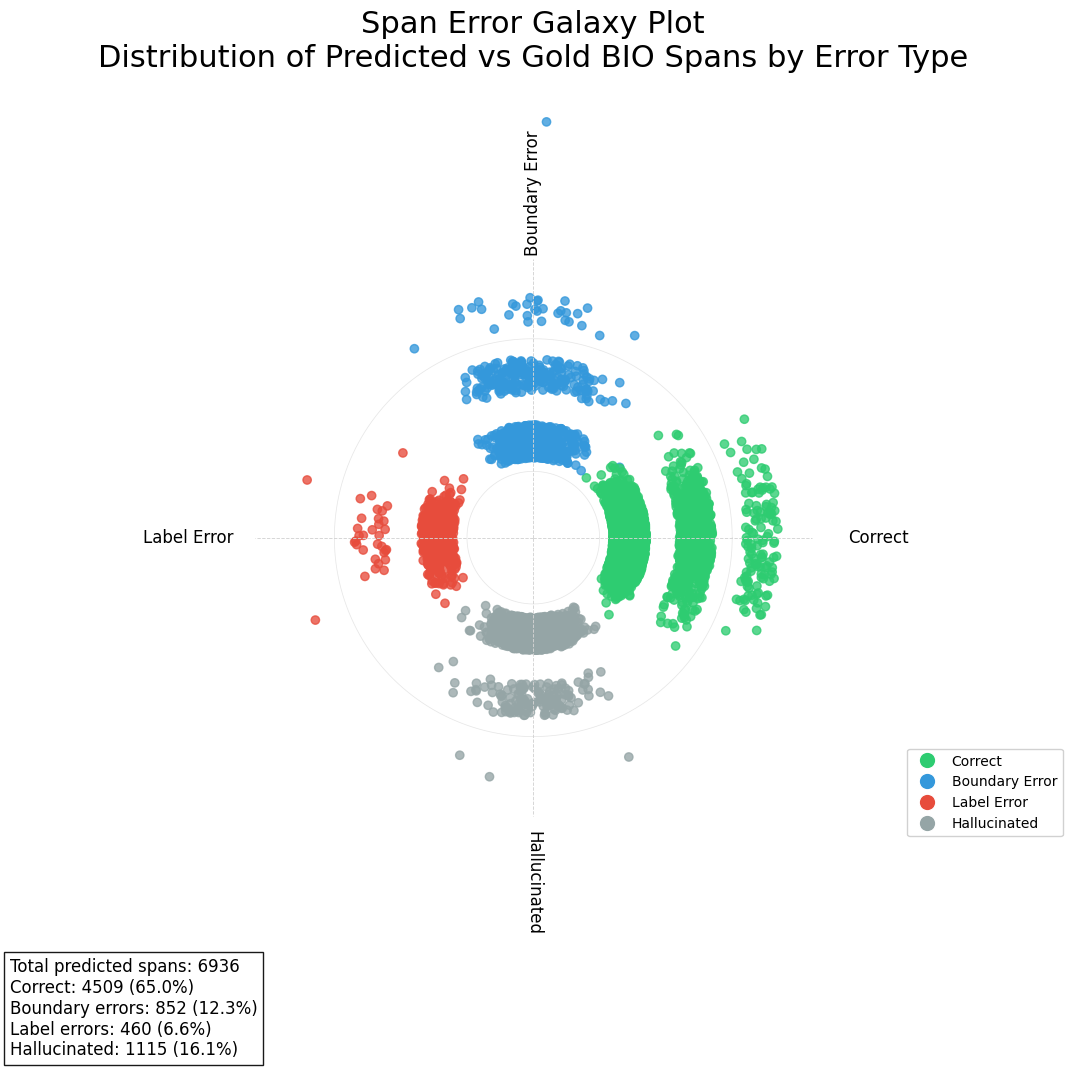

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Extract gold spans
def gold_spans_from_example(ex):
    return [(ent["type"], ent["token_start"], ent["token_end"]) for ent in ex["entities"]]

# [Gen AI Log #4 / Span Categorization]
# Categorize predicted spans
def categorize_span(gold_spans, pred_span):
    plab, ps, pe = pred_span
    gold_set = set(gold_spans)

    # exact match
    if pred_span in gold_set:
        return "correct"

    # boundary overlap
    for lab, gs, ge in gold_spans:
        if lab == plab:
            if (ps >= gs and ps < ge) or (pe > gs and pe <= ge):
                return "boundary"

    # label mismatch but overlapping
    for lab, gs, ge in gold_spans:
        if (min(pe, ge) - max(ps, gs)) > 0:
            return "label_error"

    # otherwise hallucinated
    return "hallucinated"


# Build Galaxy Plot data
lengths = []
categories = []

for ex, pred_spans in zip(bio_examples, pred_spans_all):
    gold_spans = gold_spans_from_example(ex)
    for span in pred_spans:
        _, s, e = span
        L = max(1, e - s)
        lengths.append(L)
        categories.append(categorize_span(gold_spans, span))

lengths = np.array(lengths)

# Map each category → angular region
category_angles = {
    "correct": 0,
    "boundary": np.pi/2,
    "label_error": np.pi,
    "hallucinated": 3*np.pi/2,
}

colors = {
    "correct": "#2ecc71",
    "boundary": "#3498db",
    "label_error": "#e74c3c",
    "hallucinated": "#95a5a6",
}

# Build polar coordinates
theta = []
r = []
point_colors = []

for cat, L in zip(categories, lengths):
    base_angle = category_angles[cat]

    angle = base_angle + np.random.normal(scale=0.22)  # jitter
    radius = L + np.random.uniform(0.2, 0.7)           # jitter

    theta.append(angle)
    r.append(radius)
    point_colors.append(colors[cat])

theta = np.array(theta)
r = np.array(r)

# Summary statistics
unique, counts = np.unique(categories, return_counts=True)
stats = dict(zip(unique, counts))
total = len(categories)

# Begin Plot
plt.figure(figsize=(11, 11))
ax = plt.subplot(111, polar=True)

# Enhanced point visibility
ax.scatter(theta, r, c=point_colors, s=36, alpha=0.78)

# Radial rings (span length bins)
max_len = np.percentile(lengths, 98)
ring_steps = np.arange(1, int(max_len)+2, 2)

for rl in ring_steps:
    ax.plot(np.linspace(0, 2*np.pi, 600), np.ones(600)*rl,
            color="lightgray", linewidth=0.55, alpha=0.55)

# Quadrant separators
quad_lines = [0, np.pi/2, np.pi, 3*np.pi/2]
for q in quad_lines:
    ax.plot([q, q], [0, max_len+1.2],
            color="lightgray", linestyle="--", linewidth=0.65)

# Title
plt.title(
    "Span Error Galaxy Plot\nDistribution of Predicted vs Gold BIO Spans by Error Type",
    fontsize=22,
    pad=25,
)

# Quadrant Labels (smaller & outward)
label_radius = max_len + 2.2

quadrant_labels = [
    ("Correct",          0,          0),
    ("Boundary Error",   np.pi/2,    90),
    ("Label Error",      np.pi,      0),
    ("Hallucinated",     3*np.pi/2, -90),
]

for text, ang, rot in quadrant_labels:
    ax.text(
        ang,
        label_radius,
        text,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="normal",
        rotation=rot,
        rotation_mode="anchor"
    )

# Cleanup axes
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)
ax.set_frame_on(False)

# Embedded summary statistics
summary_text = (
    f"Total predicted spans: {total}\n"
    f"Correct: {stats.get('correct',0)} ({stats.get('correct',0)/total:.1%})\n"
    f"Boundary errors: {stats.get('boundary',0)} ({stats.get('boundary',0)/total:.1%})\n"
    f"Label errors: {stats.get('label_error',0)} ({stats.get('label_error',0)/total:.1%})\n"
    f"Hallucinated: {stats.get('hallucinated',0)} ({stats.get('hallucinated',0)/total:.1%})"
)

plt.text(
    0.03, 0.03,
    summary_text,
    transform=plt.gcf().transFigure,
    fontsize=12,
    bbox=dict(facecolor="white", alpha=0.9, edgecolor="black"),
)

# Legend moved bottom-left
handles = [
    plt.Line2D([0],[0], marker='o', color='w',
               label="Correct", markerfacecolor=colors["correct"], markersize=12),
    plt.Line2D([0],[0], marker='o', color='w',
               label="Boundary Error", markerfacecolor=colors["boundary"], markersize=12),
    plt.Line2D([0],[0], marker='o', color='w',
               label="Label Error", markerfacecolor=colors["label_error"], markersize=12),
    plt.Line2D([0],[0], marker='o', color='w',
               label="Hallucinated", markerfacecolor=colors["hallucinated"], markersize=12),
]

plt.legend(
    handles=handles,
    loc="lower left",
    bbox_to_anchor=(0.92, 0.15),
    frameon=True,
    facecolor="white",
    framealpha=0.9
)

plt.tight_layout()
plt.show()


<br>

#### Gen AI Reference Log

Some model development steps were tested using Generative AI tools (Copilot, ChatGPT 4o+, September 2025 version) as reference for debugging and conceptual clarification under the guidance of the course’s AI Technologies Policy.

Prompts and interactions below are representative of the queries used during development:

1. Initialization of flattened token-label arrays  
   Prompt: Ask whether token-level confusion matrices require every token to receive a default non-entity label before span projection.  
   Context: Assistant verified that initializing gold and predicted sequences with "O" is necessary to prevent uninitialized positions from biasing the confusion matrix or leading to mismatches in vector lengths. It also affirmed that defining g and p with size n = len(tokens) ensures strict token-level alignment independent of span-level labels.  

2. Aggregation of global gold and predicted span sets  
   Prompt: Ask whether span-level metrics should operate on flattened sets across all documents rather than document-aligned lists.  
   Context: Assistant explained that aggregated-set evaluation is standard for strict span-level metrics because it simplifies global precision and recall computation. Document-level aggregation would be necessary only for per-document metrics or significance testing, neither of which were required here.  

3. Identification of all development-set mismatched examples  
   Prompt: Ask whether using set comparisons across all spans is the correct approach for identifying mismatches.  
   Context: Assistant confirmed that computing G_spans = set(gold_spans_from_example(ex)) and P_spans = pred_spans_all[i] followed by if G_spans != P_spans correctly identifies examples where span sets differ in any way. This captures missing entities, hallucinated entities, label errors, and boundary errors. Set comparison was validated as both precise and computationally efficient.  

4. Span categorization logic and error taxonomy  
   Prompt: Ask whether the ordering of tests should prioritize exact matches, then boundary errors, then label mismatches, and finally hallucinations.  
   Context: Assistant verified this hierarchical evaluation order as correct and standard in error analysis for NER. Specifically:  
   Exact match must be checked first.  
   Boundary errors are identified next by type-correct but boundary-inexact spans.  
   Label errors are spans overlapping in boundary but mismatched in entity type.  
   Remaining spans are hallucinated predictions.  
   This sequence ensures mutually exclusive categories and produces interpretable plots.


<br><br>


---


<br><br>